In [1]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import plotly.express as px
from datetime import datetime
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
play_store_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\Play Store Data.csv")
play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
reviews_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\User Reviews.csv")
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
play_store_df = play_store_df.drop_duplicates(subset="App")
play_store_df.shape

(9660, 13)

In [6]:
play_store_df.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [7]:
play_store_df["Rating"] = play_store_df["Rating"].fillna(
    play_store_df["Rating"].median()
)

play_store_df["Type"] = play_store_df["Type"].fillna(
    play_store_df["Type"].mode()[0]
)

play_store_df["Content Rating"] = play_store_df[
    "Content Rating"
].fillna(
    play_store_df["Content Rating"].mode()[0]
)

play_store_df["Current Ver"] = play_store_df[
    "Current Ver"
].fillna(
    play_store_df["Current Ver"].mode()[0]
)

play_store_df["Android Ver"] = play_store_df[
    "Android Ver"
].fillna(
    play_store_df["Android Ver"].mode()[0]
)

In [8]:
play_store_df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [9]:
play_store_df = play_store_df[play_store_df["Installs"] != "Free"]
play_store_df["Installs_Num"] = (

    play_store_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)

)
play_store_df[
    ["Installs", "Installs_Num"]
].head()

,Installs,Installs_Num
0,"10,000+",10000.0
1,"500,000+",500000.0
2,"5,000,000+",5000000.0
3,"50,000,000+",50000000.0
4,"100,000+",100000.0


In [10]:
play_store_df["Price"] = (
    play_store_df["Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

In [11]:
play_store_df[
    ["Price"]
].head()

,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [12]:
play_store_df = play_store_df[
    play_store_df["Size"] != "Varies with device"
].copy()

In [13]:
play_store_df["Size"] = play_store_df["Size"].apply(
    lambda x: float(x[:-1])
    if str(x).endswith("M")
    else float(x[:-1]) / 1024
    if str(x).endswith("k")
    else np.nan
)

In [14]:
play_store_df[
    ["Size"]
].head()

,Size
0,19.0
1,14.0
2,8.7
3,25.0
4,2.8


In [15]:
play_store_df["Android_Version"] = (
    play_store_df["Android Ver"]
    .str.extract(r"(\d+\.\d+)")
)
play_store_df["Android_Version"] = pd.to_numeric(
    play_store_df["Android_Version"],
    errors="coerce"
)
play_store_df[
    ["Android Ver", "Android_Version"]
].head(10)

,Android Ver,Android_Version
0,4.0.3 and up,4.0
1,4.0.3 and up,4.0
2,4.0.3 and up,4.0
3,4.2 and up,4.2
4,4.4 and up,4.4
5,2.3 and up,2.3
6,4.0.3 and up,4.0
7,4.2 and up,4.2
8,3.0 and up,3.0
9,4.0.3 and up,4.0


In [16]:
play_store_df["Revenue"] = (
    play_store_df["Price"] *
    play_store_df["Installs_Num"]
)
play_store_df[
    ["Price", "Installs_Num", "Revenue"]
].head()

,Price,Installs_Num,Revenue
0,0.0,10000.0,0.0
1,0.0,500000.0,0.0
2,0.0,5000000.0,0.0
3,0.0,50000000.0,0.0
4,0.0,100000.0,0.0


In [17]:
filtered_df = play_store_df[
    (play_store_df["Installs_Num"] >= 10000)
]

filtered_df = filtered_df[
    (
        (filtered_df["Type"] == "Free")
        |
        (filtered_df["Revenue"] >= 10000)
    )
]

filtered_df = filtered_df[
    filtered_df["Android_Version"] > 4.0
]

filtered_df = filtered_df[
    filtered_df["Size"] > 15
]

filtered_df = filtered_df[
    filtered_df["Content Rating"] == "Everyone"
]

filtered_df = filtered_df[
    filtered_df["App"].str.len() <= 30
]

In [18]:
filtered_df.shape

(875, 16)

In [19]:
top_categories = (
    play_store_df[
        (play_store_df["Installs_Num"] >= 10000) &
        (play_store_df["Android_Version"] > 4.0) &
        (play_store_df["Size"] > 15) &
        (play_store_df["Content Rating"] == "Everyone") &
        (play_store_df["App"].str.len() <= 30)
    ]
    .groupby("Category")["Installs_Num"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)
filtered_df = filtered_df[
    filtered_df["Category"].isin(top_categories)
]

In [20]:
summary = (
    filtered_df.groupby(
        ["Category", "Type"]
    )[["Installs_Num", "Revenue"]]
    .mean()
    .reset_index()
)

In [21]:
summary

,Category,Type,Installs_Num,Revenue
0,FAMILY,Free,6.423557e+06,0.000000
1,FAMILY,Paid,3.616667e+05,597216.666667
2,GAME,Free,3.319490e+07,0.000000
3,GAME,Paid,6.714286e+04,276471.428571
4,TOOLS,Free,2.148290e+07,0.000000
5,TOOLS,Paid,1.000000e+05,449000.000000


In [22]:
fig = make_subplots(
    specs=[[{"secondary_y": True}]]
)
for app_type in summary["Type"].unique():

    temp = summary[
        summary["Type"] == app_type
    ]

    fig.add_trace(
        go.Bar(
            x=temp["Category"],
            y=temp["Installs_Num"],
            name=f"{app_type} Avg Installs"
        ),
        secondary_y=False
    )

In [23]:
for app_type in summary["Type"].unique():

    temp = summary[
        summary["Type"] == app_type
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["Category"],
            y=temp["Revenue"],
            mode="lines+markers",
            marker=dict(size=10),
            line=dict(width=3),
            name=f"{app_type} Revenue"
        ),
        secondary_y=True
    )

In [24]:
summary

,Category,Type,Installs_Num,Revenue
0,FAMILY,Free,6.423557e+06,0.000000
1,FAMILY,Paid,3.616667e+05,597216.666667
2,GAME,Free,3.319490e+07,0.000000
3,GAME,Paid,6.714286e+04,276471.428571
4,TOOLS,Free,2.148290e+07,0.000000
5,TOOLS,Paid,1.000000e+05,449000.000000


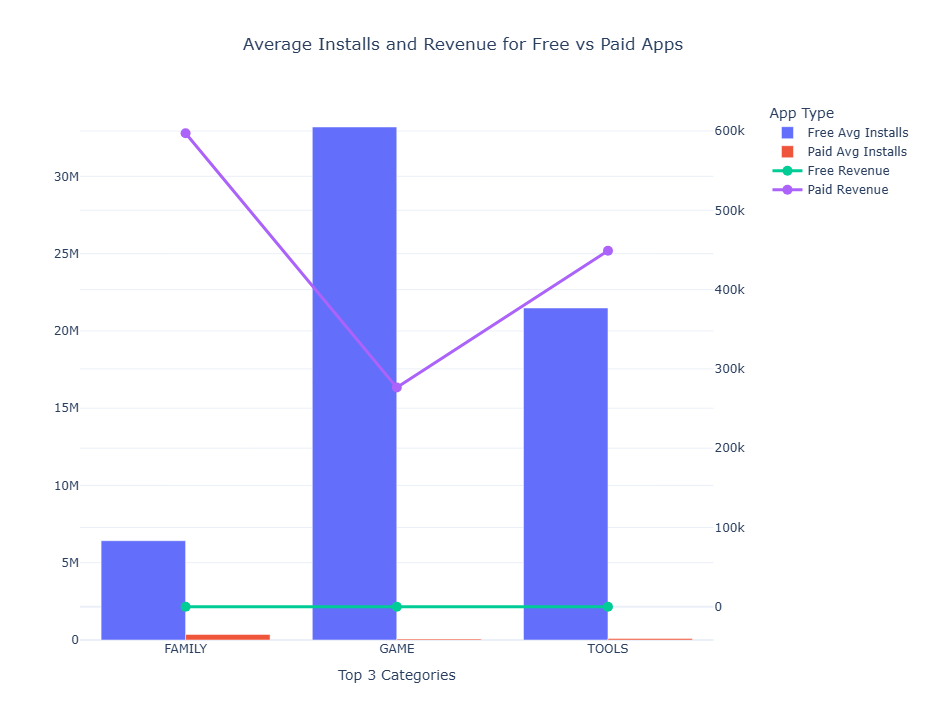

In [25]:
fig.update_layout(
    title={
        "text": "Average Installs and Revenue for Free vs Paid Apps",
        "x": 0.5
    },
    xaxis_title="Top 3 Categories",
    legend_title="App Type",
    template="plotly_white",
    hovermode="x unified",
    width=1400,
    height=700,
    legend=dict(
        x=1.02,
        y=1
    )
)

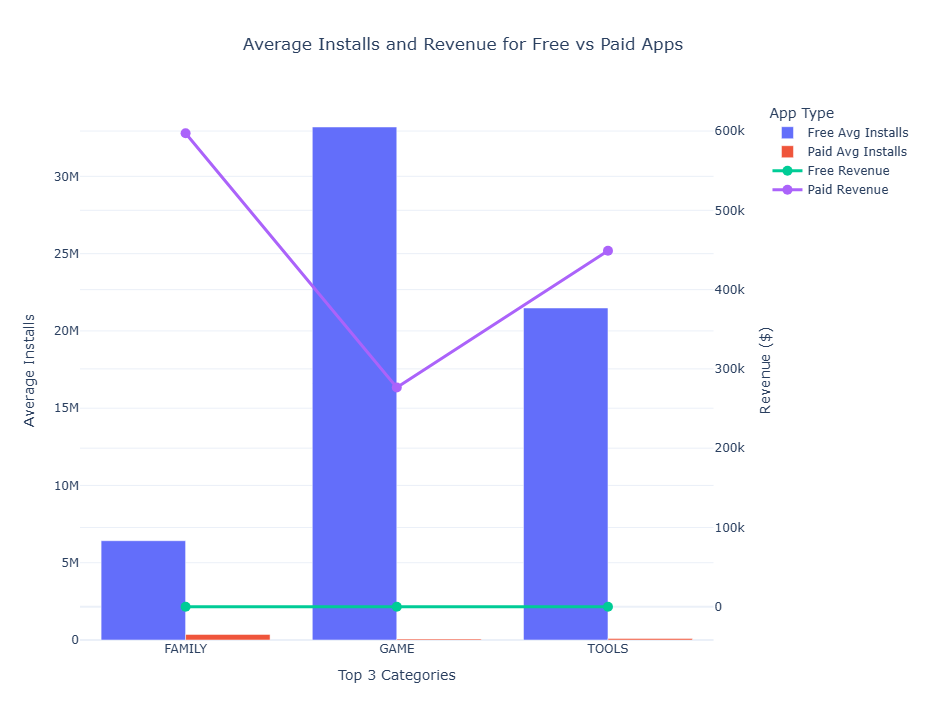

In [26]:
fig.update_yaxes(
    title_text="Average Installs",
    secondary_y=False
)

fig.update_yaxes(
    title_text="Revenue ($)",
    secondary_y=True
)

In [27]:
current_hour = datetime.now().hour

if 13 <= current_hour < 14:
    fig.show()
else:
    print(
        "This graph is available only between 1 PM IST and 2 PM IST."
    )

This graph is available only between 1 PM IST and 2 PM IST.


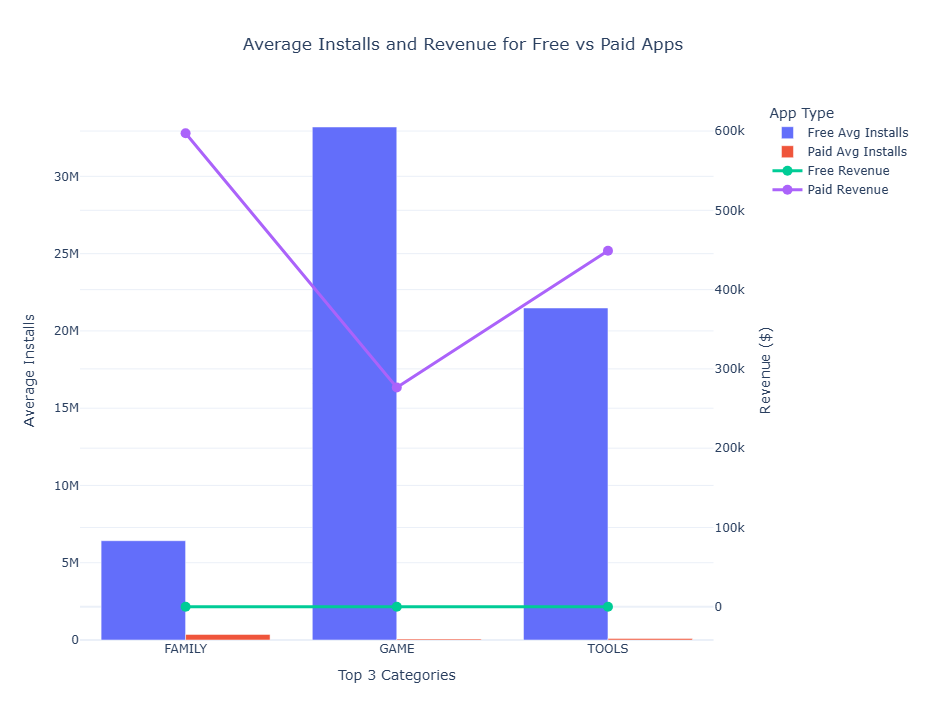

In [28]:
current_hour = 13
if 13 <= current_hour < 14:
    fig.show()
else:
    print(
        "This graph is available only between 1 PM IST and 2 PM IST."
    )

In [29]:
filtered_df["Type"].value_counts()

Type
Free    321
Paid     14
Name: count, dtype: int64